Dataset created successfully!
Total samples: 40

Language Distribution:
language
English    8
French     8
Spanish    8
German     8
Hindi      8
Name: count, dtype: int64

Text converted into numerical features!
Training feature shape: (30, 1044)

Naive Bayes model trained successfully!

MODEL EVALUATION
----------------
Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

     English       1.00      0.50      0.67         2
      French       1.00      1.00      1.00         2
      German       0.67      1.00      0.80         2
       Hindi       1.00      1.00      1.00         2
     Spanish       1.00      1.00      1.00         2

    accuracy                           0.90        10
   macro avg       0.93      0.90      0.89        10
weighted avg       0.93      0.90      0.89        10



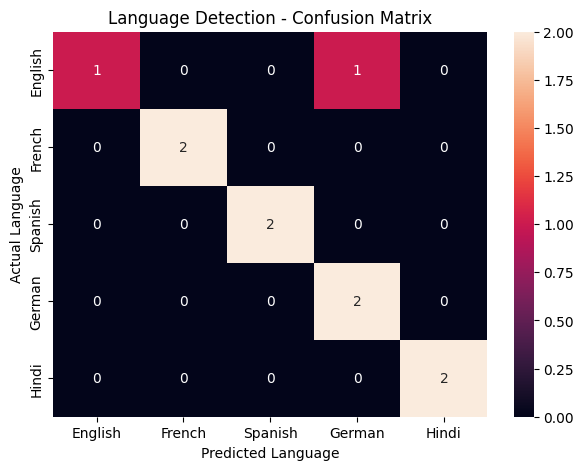


NEW TEXT PREDICTIONS
--------------------
I am learning artificial intelligence. → English
Bonjour, je suis très heureux. → French
Hola, me gusta aprender. → Spanish
Ich lerne neue Dinge. → German
मुझे हिंदी भाषा पसंद है। → Hindi


In [1]:
# Language Detection using NLP
# Model: Multinomial Naive Bayes
# Technique: TF-IDF

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# 1. Create Dataset
# -----------------------------------

data = {
    "text": [
        # English
        "Hello, how are you today?",
        "I am going to college today.",
        "I love learning new things.",
        "The weather is beautiful today.",
        "What time is the meeting?",
        "I am studying computer science.",
        "This is a wonderful day.",
        "Please send me the project details.",

        # French
        "Bonjour, comment allez-vous?",
        "Je vais au collège aujourd'hui.",
        "J'aime apprendre de nouvelles choses.",
        "Il fait beau aujourd'hui.",
        "Quelle heure est la réunion?",
        "J'étudie l'informatique.",
        "C'est une journée merveilleuse.",
        "Veuillez m'envoyer les détails du projet.",

        # Spanish
        "Hola, ¿cómo estás?",
        "Voy a la universidad hoy.",
        "Me encanta aprender cosas nuevas.",
        "El clima es hermoso hoy.",
        "¿A qué hora es la reunión?",
        "Estoy estudiando informática.",
        "Este es un día maravilloso.",
        "Por favor envíame los detalles del proyecto.",

        # German
        "Hallo, wie geht es dir?",
        "Ich gehe heute zur Universität.",
        "Ich liebe es, neue Dinge zu lernen.",
        "Das Wetter ist heute schön.",
        "Um wie viel Uhr ist das Treffen?",
        "Ich studiere Informatik.",
        "Heute ist ein wunderbarer Tag.",
        "Bitte senden Sie mir die Projektdetails.",

        # Hindi
        "नमस्ते, आप कैसे हैं?",
        "मैं आज कॉलेज जा रहा हूँ।",
        "मुझे नई चीजें सीखना पसंद है।",
        "आज मौसम बहुत अच्छा है।",
        "बैठक कितने बजे है?",
        "मैं कंप्यूटर विज्ञान पढ़ रहा हूँ।",
        "आज एक बहुत अच्छा दिन है।",
        "कृपया मुझे प्रोजेक्ट की जानकारी भेजें।"
    ],

    "language": [
        "English","English","English","English",
        "English","English","English","English",

        "French","French","French","French",
        "French","French","French","French",

        "Spanish","Spanish","Spanish","Spanish",
        "Spanish","Spanish","Spanish","Spanish",

        "German","German","German","German",
        "German","German","German","German",

        "Hindi","Hindi","Hindi","Hindi",
        "Hindi","Hindi","Hindi","Hindi"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Total samples:", len(df))

print("\nLanguage Distribution:")
print(df["language"].value_counts())

# -----------------------------------
# 2. Train-Test Split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["language"],
    test_size=0.25,
    random_state=42,
    stratify=df["language"]
)

# -----------------------------------
# 3. TF-IDF Feature Extraction
# -----------------------------------

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(1, 3)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nText converted into numerical features!")
print("Training feature shape:", X_train_tfidf.shape)

# -----------------------------------
# 4. Train Model
# -----------------------------------

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("\nNaive Bayes model trained successfully!")

# -----------------------------------
# 5. Prediction
# -----------------------------------

predictions = model.predict(X_test_tfidf)

# -----------------------------------
# 6. Evaluation
# -----------------------------------

accuracy = accuracy_score(y_test, predictions)

print("\nMODEL EVALUATION")
print("----------------")
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# -----------------------------------
# 7. Confusion Matrix
# -----------------------------------

labels = ["English", "French", "Spanish", "German", "Hindi"]

cm = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Language")
plt.ylabel("Actual Language")
plt.title("Language Detection - Confusion Matrix")
plt.show()

# -----------------------------------
# 8. Test New Sentences
# -----------------------------------

new_text = [
    "I am learning artificial intelligence.",
    "Bonjour, je suis très heureux.",
    "Hola, me gusta aprender.",
    "Ich lerne neue Dinge.",
    "मुझे हिंदी भाषा पसंद है।"
]

new_features = vectorizer.transform(new_text)
new_predictions = model.predict(new_features)

print("\nNEW TEXT PREDICTIONS")
print("--------------------")

for text, prediction in zip(new_text, new_predictions):
    print(f"{text} → {prediction}")